In [1]:
import pandas as pd
import matplotlib.pyplot as plt



In [2]:
datos_limpios= pd.read_pickle('../data/datos_arbolado')
datos_limpios

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,Esmeralda,1000.0,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,Pellegrini Carlos,1300.0,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,Arroyo,800.0,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,Arroyo,900.0,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,Arroyo,900.0,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
370051,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,2.0,Regular,1.0,83.0,20.0
370052,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,2.0,Regular,1.0,76.0,20.0
370053,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,2.0,Regular,1.0,85.0,20.0
370054,-58.468342,-34.587871,15.0,Estomba,300.0,<NA>,Tipuana tipu,4.0,2.0,Regular,1.0,84.0,20.0


In [3]:
datos_limpios['nombre_cientifico'].value_counts()
datos_limpios.to_csv('../data/datos.csv')

In [4]:
datos_limpios.head()

,long,lat,comuna,calle_nombre,calle_altura,calle_chapa,nombre_cientifico,ancho_acera,estado_plantera,ubicacion_plantera,nivel_plantera,diametro_altura_pecho,altura_arbol
0,-58.378563,-34.594902,1.0,Esmeralda,1000.0,11200,Tipuana tipu,5.5,2.0,Regular,1.0,88.0,34.0
1,-58.381532,-34.592319,1.0,Pellegrini Carlos,1300.0,13450,Otra,4.5,2.0,Regular,2.0,6.0,5.0
2,-58.379103,-34.591939,1.0,Arroyo,800.0,8480,Fraxinus pennsylvanica,4.0,2.0,Regular,1.0,7.0,6.0
5,-58.381043,-34.591584,1.0,Arroyo,900.0,9700,Fraxinus pennsylvanica,3.5,2.0,Regular,1.0,29.0,15.0
6,-58.380968,-34.591576,1.0,Arroyo,900.0,9620,Fraxinus pennsylvanica,4.5,2.0,Regular,1.0,21.0,12.0


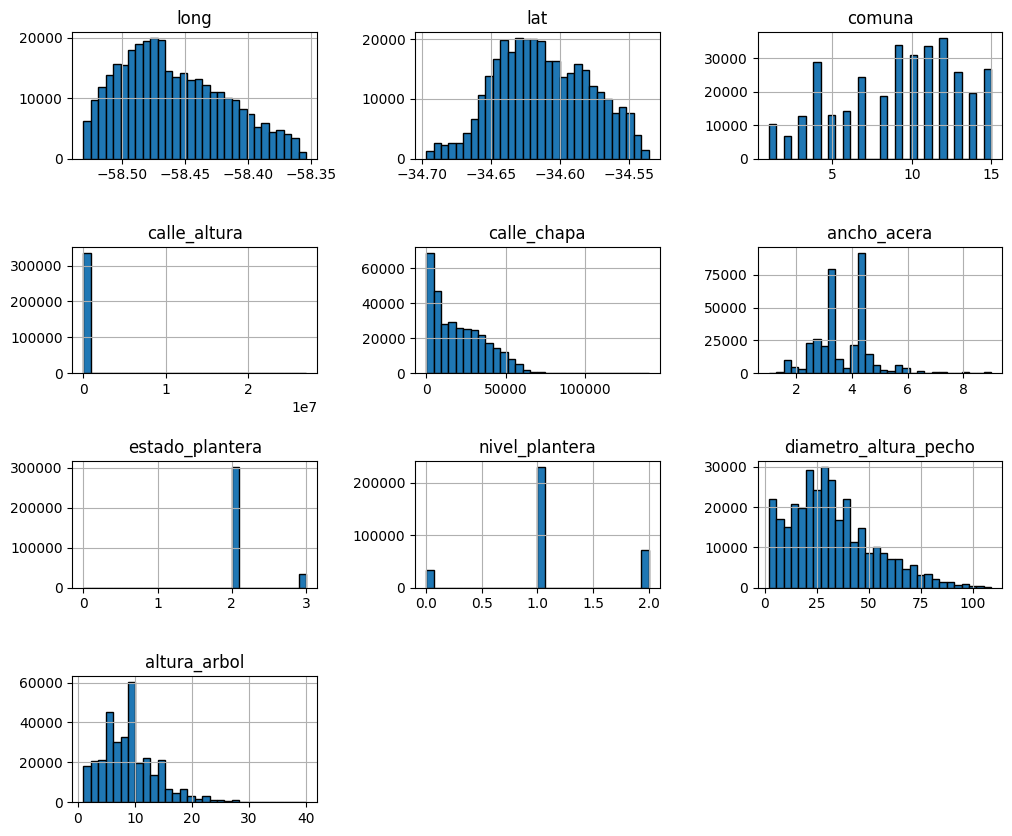

In [5]:
datos_limpios.hist(figsize=(12, 10), bins=30, edgecolor="black")
plt.subplots_adjust(hspace=0.7, wspace=0.4)

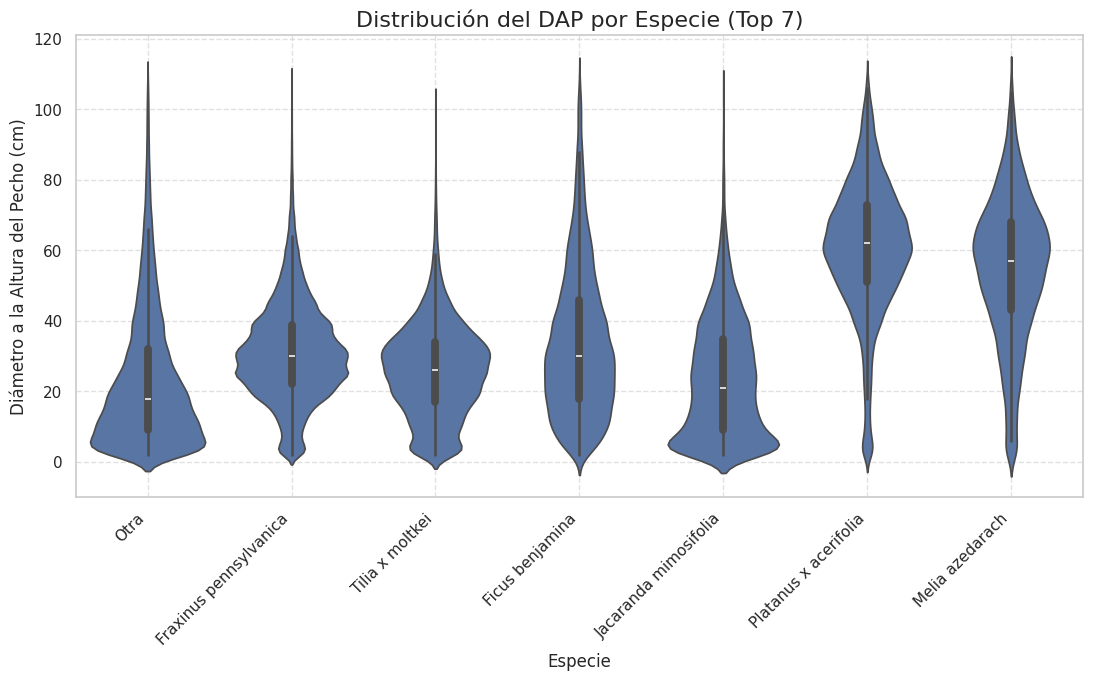

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la lista de las 7 especies más comunes
top_species = datos_limpios['nombre_cientifico'].value_counts().nlargest(7).index

# 2. Filtramos el DataFrame para incluir solo esas especies
df_top_species = datos_limpios[
    datos_limpios['nombre_cientifico'].isin(top_species)
]

# 3. Creamos el Violin Plot
plt.figure(figsize=(13, 6))
sns.violinplot(
    data=df_top_species, 
    x='nombre_cientifico', 
    y='diametro_altura_pecho'
)
plt.title('Distribución del DAP por Especie (Top 7)', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

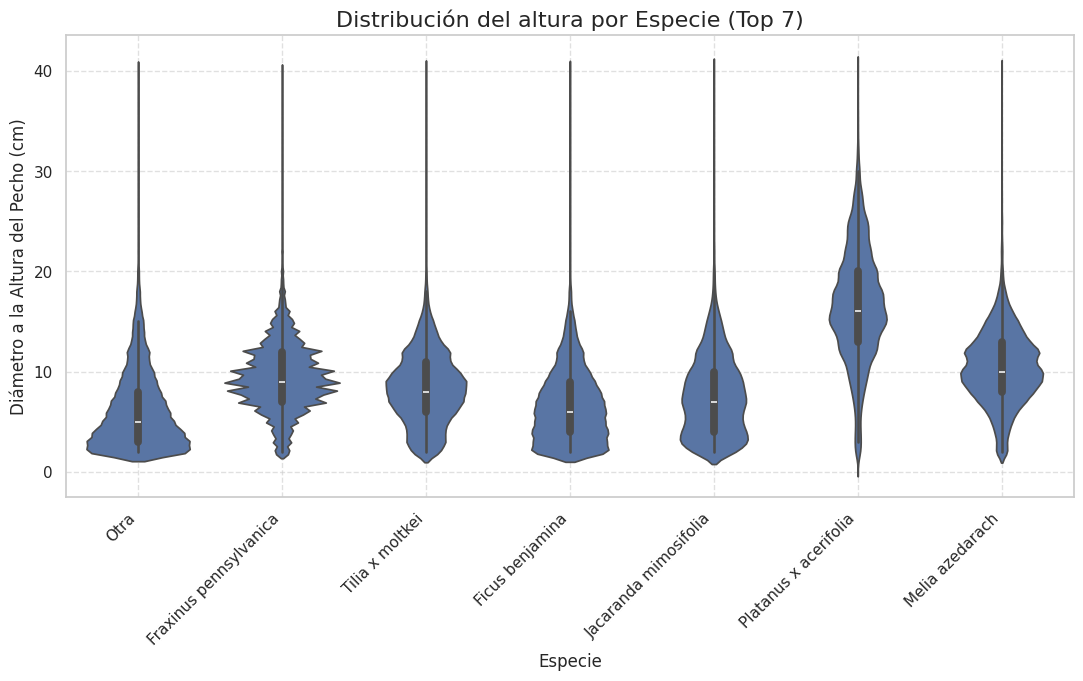

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la lista de las 7 especies más comunes
top_species = datos_limpios['nombre_cientifico'].value_counts().nlargest(7).index

# 2. Filtramos el DataFrame para incluir solo esas especies
df_top_species = datos_limpios[
    datos_limpios['nombre_cientifico'].isin(top_species)
]

# 3. Creamos el Violin Plot
plt.figure(figsize=(13, 6))
sns.violinplot(
    data=df_top_species, 
    x='nombre_cientifico', 
    y='altura_arbol'
)
plt.title('Distribución del altura por Especie (Top 7)', fontsize=16)
plt.xlabel('Especie', fontsize=12)
plt.ylabel('Diámetro a la Altura del Pecho (cm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
from scipy.stats import kruskal

# Supongamos que tus datos individuales están en 'datos_limpios' con la variable cluster asignada
variables = ['diametro_altura_pecho', 'altura_arbol']

for var in variables:
    grupos = [datos_limpios.loc[datos_limpios['nombre_cientifico'] == c, var] for c in sorted(datos_limpios['nombre_cientifico'].unique())]
    stat, p = kruskal(*grupos)
    print(f'{var}: estadístico H = {stat:.3f}, p = {p:.5f}')


diametro_altura_pecho: estadístico H = 104789.814, p = 0.00000
altura_arbol: estadístico H = 110925.572, p = 0.00000


In [53]:
import scikit_posthocs as sp
import pandas as pd

especie_objetivo = 'Platanus x acerifolia'   # Ajustar al nombre EXACTO en tu dataset
variables = ['diametro_altura_pecho', 'altura_arbol']

for var in variables:
    print(f'\nPOSTHOC VS {especie_objetivo.upper()} PARA {var.upper()}')

    # Posthoc Dunn con corrección de Holm
    dunn = sp.posthoc_dunn(
        datos_limpios,
        val_col=var,
        group_col='nombre_cientifico',
        p_adjust='holm'
    )

    # Extraer solo la fila correspondiente a Platanus
    pvals = dunn.loc[especie_objetivo, :]

    # Quitar self-comparison
    pvals = pvals.drop(index=especie_objetivo)

    # Crear DataFrame final
    comparaciones = pd.DataFrame({
        'p_valor': pvals,
        'significativa': pvals < 0.05
    })

    print(comparaciones)



POSTHOC VS PLATANUS X ACERIFOLIA PARA DIAMETRO_ALTURA_PECHO
                                           p_valor  significativa
Acer negundo                          0.000000e+00           True
Ficus benjamina                       0.000000e+00           True
Fraxinus americana                    0.000000e+00           True
Fraxinus excelsior                    0.000000e+00           True
Fraxinus pennsylvanica                0.000000e+00           True
Jacaranda mimosifolia                 0.000000e+00           True
Lagerstroemia indica                  0.000000e+00           True
Ligustrum lucidum                     0.000000e+00           True
Ligustrum lucidum f. aureovariegata   0.000000e+00           True
Liquidambar styraciflua               0.000000e+00           True
Melia azedarach                       1.190687e-87           True
Otra                                  0.000000e+00           True
Persea americana                      0.000000e+00           True
Robinia pseudoa


VARIABLE: diametro_altura_pecho
                  nombre_cientifico      n media  ci95   p_valor significativa_vs_platanus
              Platanus x acerifolia  29570 60.69 ±0.22  1.00e+00                        No
                    Melia azedarach  13882 54.68 ±0.34  1.19e-87                        Sí
                       Tipuana tipu   7333 52.24 ±0.55 2.12e-176                        Sí
            Styphnolobium japonicum   2060 39.02 ±0.73 6.06e-244                        Sí
                       Acer negundo   4869 35.66 ±0.48  0.00e+00                        Sí
                    Ficus benjamina  21087 34.05 ±0.28  0.00e+00                        Sí
             Fraxinus pennsylvanica 127674 31.28 ±0.08  0.00e+00                        Sí
                 Fraxinus americana   9605 30.96 ±0.29  0.00e+00                        Sí
                 Fraxinus excelsior   8182 29.59 ±0.30  0.00e+00                        Sí
               Robinia pseudoacacia   1824 28.32 ±0.75  0

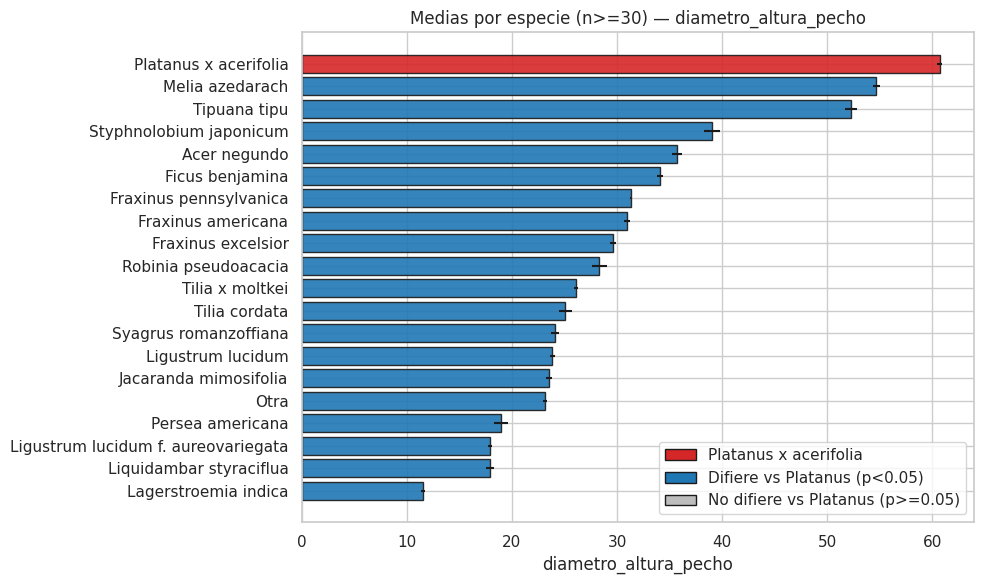


Resumen rápido: de 20 especies con n>=30, 19 difieren estadísticamente de Platanus x acerifolia (post-hoc Dunn, Holm).

VARIABLE: altura_arbol
                  nombre_cientifico      n media  ci95   p_valor significativa_vs_platanus
              Platanus x acerifolia  29570 16.61 ±0.06  1.00e+00                        No
                       Tipuana tipu   7333 14.82 ±0.15 9.14e-131                        Sí
                    Melia azedarach  13882 10.40 ±0.06  0.00e+00                        Sí
                 Fraxinus americana   9605  9.44 ±0.07  0.00e+00                        Sí
             Fraxinus pennsylvanica 127674  9.43 ±0.02  0.00e+00                        Sí
                 Fraxinus excelsior   8182  9.10 ±0.07  0.00e+00                        Sí
                       Acer negundo   4869  8.64 ±0.09  0.00e+00                        Sí
                      Tilia cordata   2041  8.46 ±0.17  0.00e+00                        Sí
                    Tilia x moltkei  

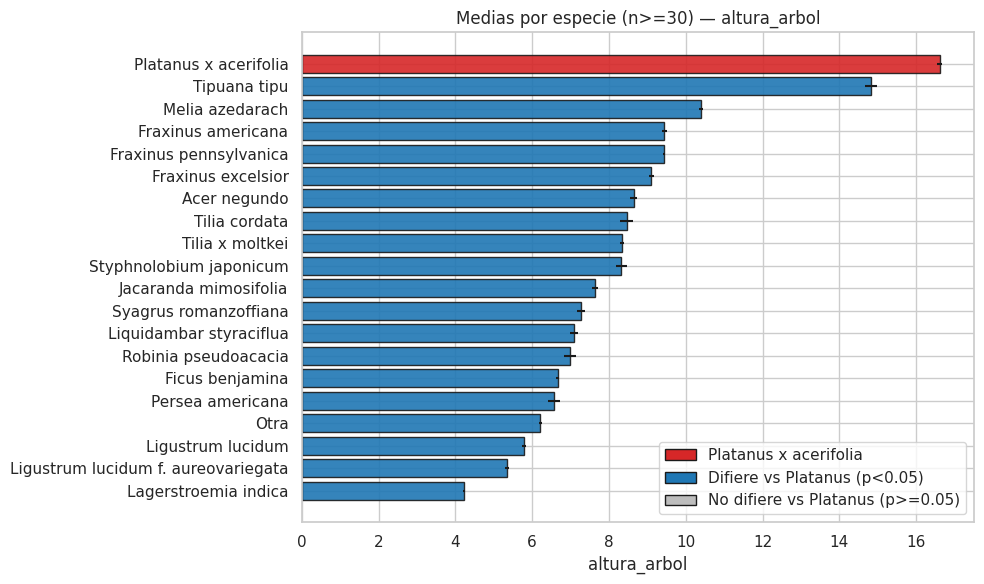


Resumen rápido: de 20 especies con n>=30, 19 difieren estadísticamente de Platanus x acerifolia (post-hoc Dunn, Holm).


In [55]:
# Requisitos: pandas, numpy, matplotlib, seaborn, scikit-posthocs, scipy
# pip install scikit-posthocs seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scikit_posthocs as sp
from scipy import stats

# Parámetros (ajustá según convenga)
especie_objetivo = 'Platanus x acerifolia'   # nombre EXACTO en tu dataset
variables = ['diametro_altura_pecho', 'altura_arbol']
min_count = 30   # mínimo de ejemplares por especie para incluir en la comparación/plot

# Función para calcular IC95 de la media (usando t para muestras pequeñas)
def mean_ci95(x):
    x = np.array(x.dropna())
    n = len(x)
    if n == 0:
        return (np.nan, np.nan, n)
    mean = x.mean()
    sem = stats.sem(x) if n > 1 else np.nan
    # t-critico con df = n-1, a 0.975
    if n > 1:
        tcrit = stats.t.ppf(0.975, df=n-1)
        ci = sem * tcrit
    else:
        ci = np.nan
    return mean, ci, n

for var in variables:
    print('\n' + '='*80)
    print(f'VARIABLE: {var}')
    print('='*80)
    # 1) Resumen por especie
    resumen = datos_limpios.groupby('nombre_cientifico')[var].apply(mean_ci95).rename('stats').reset_index()
    resumen[['media', 'ci95', 'n']] = pd.DataFrame(resumen['stats'].tolist(), index=resumen.index)
    resumen = resumen.drop(columns='stats')
    # Filtrar por n
    resumen = resumen.sort_values('media', ascending=False)
    resumen_filtered = resumen[resumen['n'] >= min_count].copy()
    if resumen_filtered.empty:
        print(f'No hay especies con al menos {min_count} observaciones para la variable {var}. Reduce min_count.')
        continue

    # 2) Post-hoc Dunn (Holm) sobre todas las especies
    dunn = sp.posthoc_dunn(datos_limpios, val_col=var, group_col='nombre_cientifico', p_adjust='holm')

    # Extraer p-vals vs Platanus
    if especie_objetivo not in dunn.index:
        raise ValueError(f"Especie objetivo '{especie_objetivo}' no encontrada en la columna 'nombre_cientifico'. Revisa el nombre exacto.")
    pvals_vs_platanus = dunn.loc[especie_objetivo, :].drop(index=especie_objetivo)
    pvals_vs_platanus = pvals_vs_platanus.rename('p_valor').reset_index().rename(columns={'index':'nombre_cientifico'})

    # 3) Mezclar con el resumen (solo especies con n >= min_count)
    resumen_plot = resumen_filtered.merge(pvals_vs_platanus, on='nombre_cientifico', how='left')
    resumen_plot['p_valor'] = resumen_plot['p_valor'].fillna(1.0)  # si no existe p-valor (por filtrado), marcar no significativo
    resumen_plot['significativa_vs_platanus'] = resumen_plot['p_valor'] < 0.05

    # 4) Mostrar tabla lista para informe
    display_cols = ['nombre_cientifico', 'n', 'media', 'ci95', 'p_valor', 'significativa_vs_platanus']
    tabla_para_informe = resumen_plot[display_cols].sort_values('media', ascending=False).reset_index(drop=True)
    # Formateo numérico legible
    tabla_para_informe['media'] = tabla_para_informe['media'].map(lambda x: f'{x:.2f}')
    tabla_para_informe['ci95'] = tabla_para_informe['ci95'].map(lambda x: f'±{x:.2f}' if pd.notnull(x) else '±NaN')
    tabla_para_informe['p_valor'] = tabla_para_informe['p_valor'].map(lambda x: f'{x:.2e}')
    tabla_para_informe['significativa_vs_platanus'] = tabla_para_informe['significativa_vs_platanus'].map({True:'Sí', False:'No'})

    print(tabla_para_informe.to_string(index=False))

    # 5) Gráfico: barras de medias con IC95, especies ordenadas por media, Platanus y significativos resaltados
    plt.figure(figsize=(10, max(6, 0.2*len(tabla_para_informe))))
    order = tabla_para_informe['nombre_cientifico'].values

    # colores: Platanus en color distinto, los que difieren en otro, resto gris
    colors = []
    for name, sig in zip(tabla_para_informe['nombre_cientifico'], tabla_para_informe['significativa_vs_platanus']):
        if name == especie_objetivo:
            colors.append('#d62728')  # rojo para Platanus
        else:
            colors.append('#1f77b4' if sig == 'Sí' else '#bdbdbd')  # azul si significativo, gris si no

    means = tabla_para_informe['media'].astype(float)
    ci95 = tabla_para_informe['ci95'].str.replace('±','').astype(float)

    ax = plt.gca()
    bars = ax.barh(order, means, xerr=ci95, align='center', color=colors, edgecolor='k', alpha=0.9)
    ax.invert_yaxis()  # mayor arriba
    ax.set_xlabel(var)
    ax.set_title(f'Medias por especie (n>={min_count}) — {var}')
    # leyenda manual
    from matplotlib.patches import Patch
    legend_items = [
        Patch(facecolor='#d62728', edgecolor='k', label=especie_objetivo),
        Patch(facecolor='#1f77b4', edgecolor='k', label='Difiere vs Platanus (p<0.05)'),
        Patch(facecolor='#bdbdbd', edgecolor='k', label='No difiere vs Platanus (p>=0.05)')
    ]
    ax.legend(handles=legend_items, loc='lower right')
    plt.tight_layout()
    plt.show()

    # 6) Resumen rápido imprimible para el informe
    n_signif = tabla_para_informe['significativa_vs_platanus'].value_counts().get('Sí', 0)
    total = len(tabla_para_informe)
    print(f'\nResumen rápido: de {total} especies con n>={min_count}, {n_signif} difieren estadísticamente de {especie_objetivo} (post-hoc Dunn, Holm).')
